In [20]:
from pinnsform.util import *
from pinnsform.model import PINN, FLS, FLW, FullWavelet
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

def load_csv_to_numpy(file_path):
    df = pd.read_csv(file_path, header=None, index_col=None, sep=",")
    return np.array(df.values)

def load_csv_series(path):
    label_and_data = load_csv_to_numpy(path)
    labels = list(label_and_data[0])
    data = label_and_data.T[:,1:].astype(float)
    return data, labels 

def visualize_mesh(mesh, mesh_shape, domain):
    reshaped_mesh = np.reshape(mesh, mesh_shape)
    #[0,np.pi*2,1,0]
    plt.figure(figsize=(4,3))
    domain_extend = [domain[1][0], domain[1][1], domain[0][0], domain[0][1]]
    plt.imshow(reshaped_mesh, extent=domain_extend, aspect='auto')
    plt.xlabel('t')
    plt.ylabel('x')
    #plt.title('u(x,t)')
    plt.colorbar()
    plt.tight_layout()
    #plt.savefig('./1dreaction_pinnsformer_pred.png')
    plt.show()



In [9]:
def plot_evolution(
    value_evolution,
    evolution_label,
    title="Training loss evolution",
    xlabel="# epochs",
    ylabel_left="Log scale",
    ylabel_right="Linear scale",
    linestyle='solid',
    linear_indices=None  # Add an argument for indices to plot on the linear scale
):
    fig, ax_left = plt.subplots()
    fig.set_figheight(8)
    fig.set_figwidth(16)

    # Set the left y-axis to log scale
    ax_left.set_yscale("log")
    ax_left.set_xlabel(xlabel)
    ax_left.set_ylabel(ylabel_left)

    # Create a twin y-axis on the right with linear scale
    ax_right = ax_left.twinx()
    ax_right.set_yscale("linear")
    ax_right.set_ylabel(ylabel_right)

    ax_left.set(title=title)
    # Set default for linear_indices if None is provided
    if linear_indices is None:
        linear_indices = []

    value_evolution_list = list(value_evolution)

    #print(value_evolution, len(value_evolution))
    #print(evolution_label, len(evolution_label))

    if len(value_evolution) != len(evolution_label):
        raise ValueError("The number of value evolutions and labels must match.")
    for i, evo in enumerate(value_evolution):
        if i in linear_indices:
            # Plot on the right y-axis with linear scale
            ax_right.plot(evo, label=f"{evolution_label[i]} (linear)", linestyle=linestyle, color='black')
        else:
            # Plot on the left y-axis with log scale
            ax_left.plot(evo, label=f"{evolution_label[i]} (log)", linestyle=linestyle)

    # Add a legend for both y-axes
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.88))

In [10]:
base_dir = os.getcwd()
experiment_name = "FourModels_TS_LBFGS_200"
data_path = os.path.join(base_dir, 'results', experiment_name, 'run')

analysis_path = os.path.join(base_dir, 'analysis', experiment_name)

model_names = ["PINN", "FLS", "FLW", "FullWavelet"]

pinn_path = os.path.join(data_path, "PINN")
fls_path = os.path.join(data_path, "FLS")
flw_path = os.path.join(data_path, "FLW")
fullw_path = os.path.join(data_path, "FullWavelet")

In [12]:
device = 'cuda'

pinn = PINN(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)

fls = FLS(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)

flw = FLW(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)

fullwavelet = FullWavelet(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)

In [14]:
def visualize_solution_of_seed(model, path, seed, mesh, mesh_shape, domain):
    model.load_state_dict(torch.load(os.path.join(path, "seed_0", "model_at_200.pth")))
    prediction = f(model, mesh)
    visualize_mesh(prediction, mesh_shape, domain)

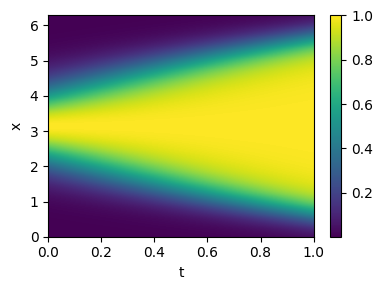

In [21]:
RHO = 5.0

def h(x):
    return np.exp( - (x-np.pi)**2 / (2 * (np.pi/4)**2))

def u_ana(x,t):
    return h(x) * np.exp(RHO*t) / ( h(x) * np.exp(RHO*t) + 1 - h(x))

problem_domain = ([0, 2*np.pi], [0, 1])

test_shape = (201, 201)
test_mesh, _ = generate_mesh_object(test_shape, domain=problem_domain, device=device, full_requires_grad=False, border_requires_grad=False)
analytic_solution = u_ana(test_mesh.part[0].cpu().numpy(), test_mesh.part[1].cpu().numpy())

visualize_mesh(analytic_solution, test_shape, problem_domain)
#visualize_solution_of_seed(pinn, pinn_path, 0, )

In [4]:
def histogram(data, title = "Distribution of First Entry Values"):
    plt.figure(figsize=(8, 6))
    # Create a histogram
    plt.hist(data, bins=20, edgecolor='black')
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.grid(True)

    # Display the plot
    plt.show()

In [5]:
NUM_SEEDS = 100
INIT_SEEDS = np.array(range(NUM_SEEDS))
#MODELS = ["PINN", "FLS", "FLW"]

In [6]:
def load_full_data(data_path):
    data = np.zeros((100, 2))
    for i in INIT_SEEDS:
        seed_path = os.path.join(data_path, f"seed_{i}", "error.csv")
        dat = load_csv_to_numpy(seed_path)
        data[i] = dat[1,:]
    return data

In [27]:
def train_history_plot(data_path, analysis_path, model_name, seed, cosine_indices = [1,3]):
    loss_path = os.path.join(data_path, model_name, f"seed_{seed}", "train_data.csv")
    train_data, train_labels = load_csv_series(loss_path)
    cosine_path = os.path.join(analysis_path, model_name, "loss_cosine_similarity", f"loss_cosine_history_seed_{seed}.csv")
    cosine_data, cosine_labels = load_csv_series(cosine_path)
    print(seed)
    if cosine_data.shape[1] > 50:
        all_data = np.append(train_data[:3,:min(cosine_data.shape[1],200)],cosine_data[cosine_indices,:min(cosine_data.shape[1],200)], axis=0)
        all_labels = np.append(train_labels[:3], np.array(cosine_labels)[cosine_indices], axis=0)
        plot_evolution(all_data, all_labels, title = model_name, linear_indices=[6])
        plt.show()

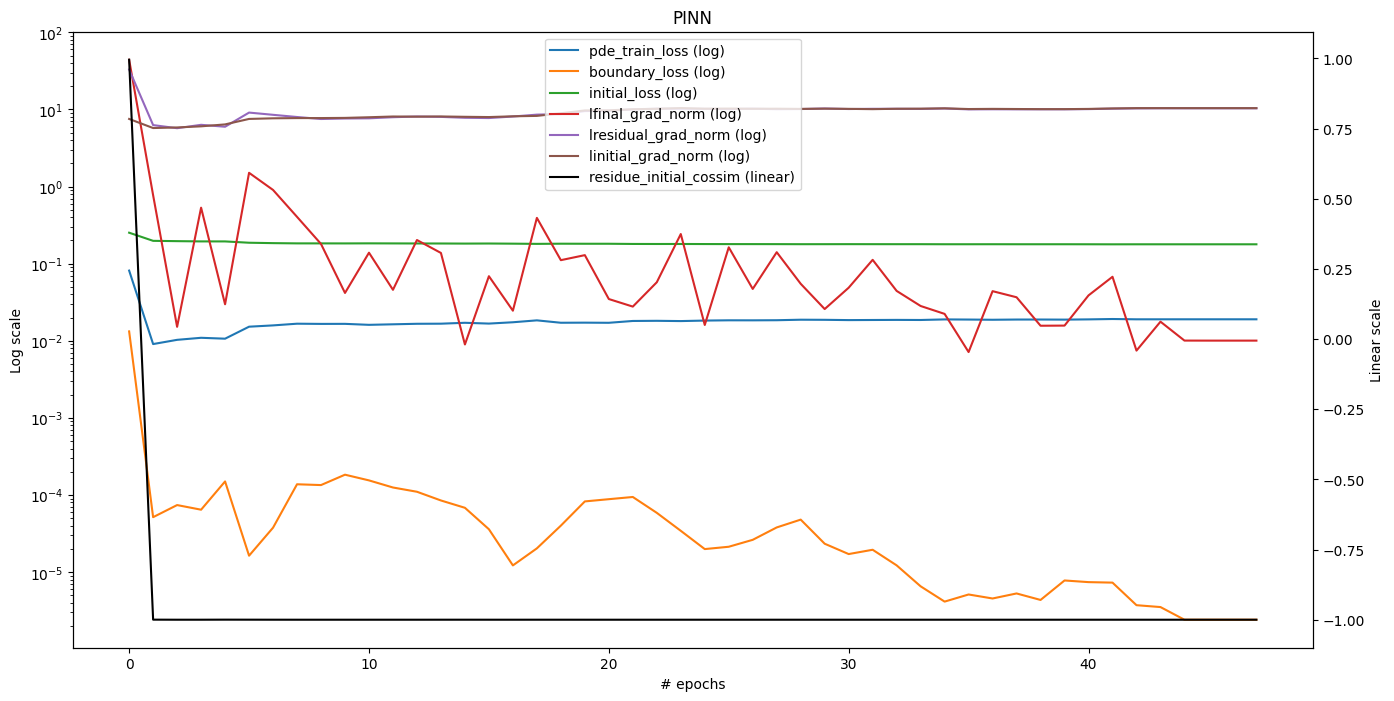

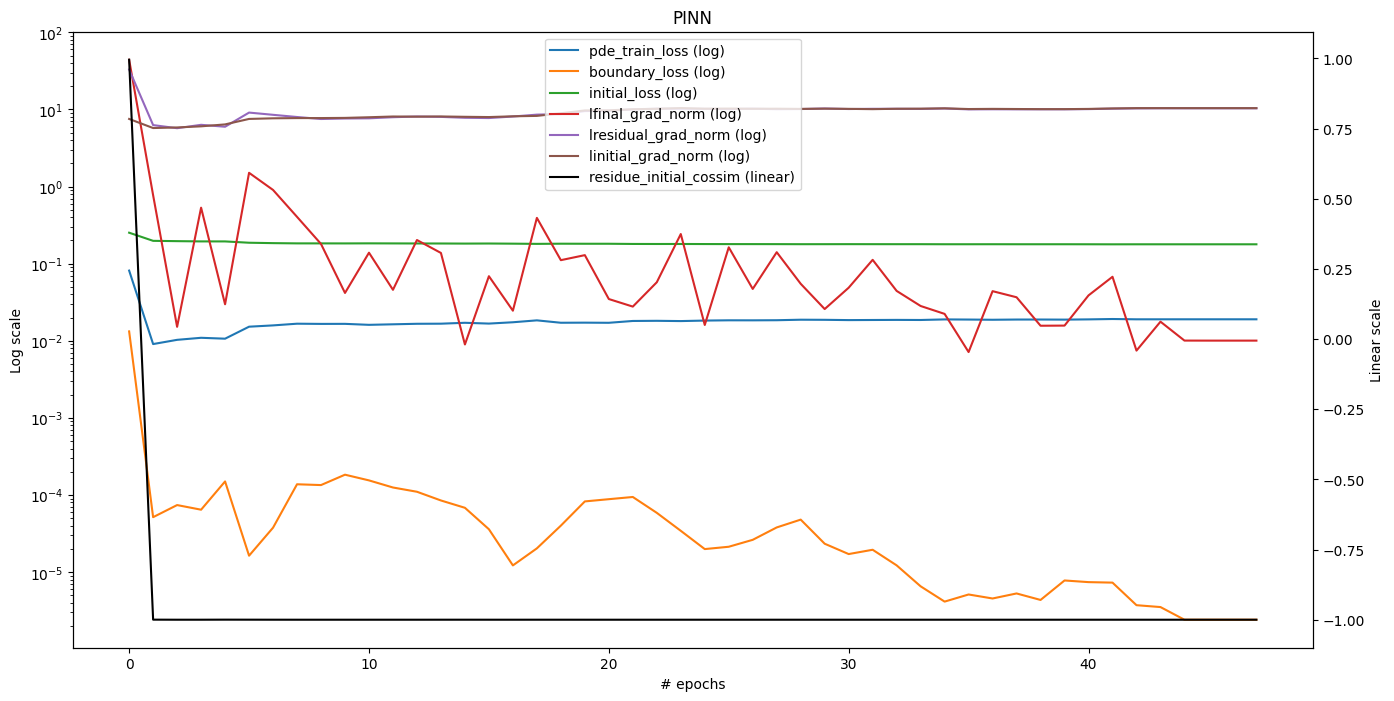

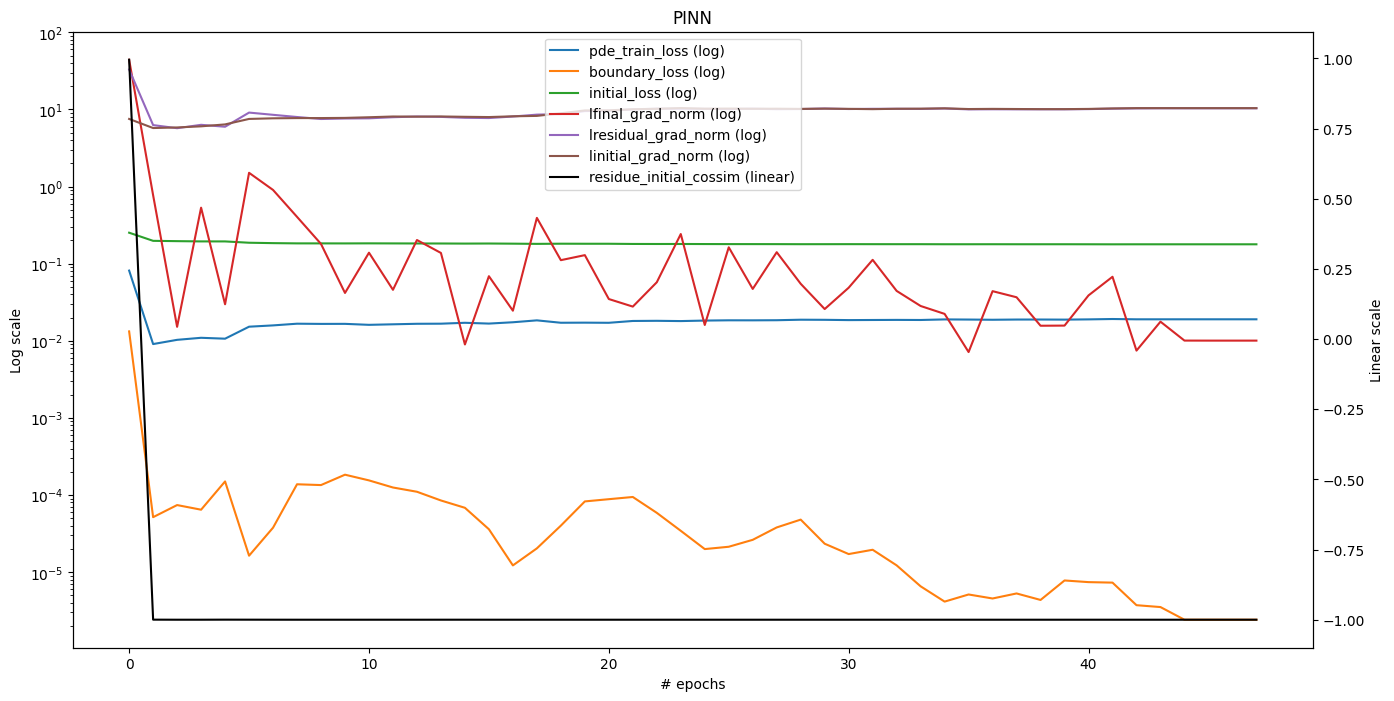

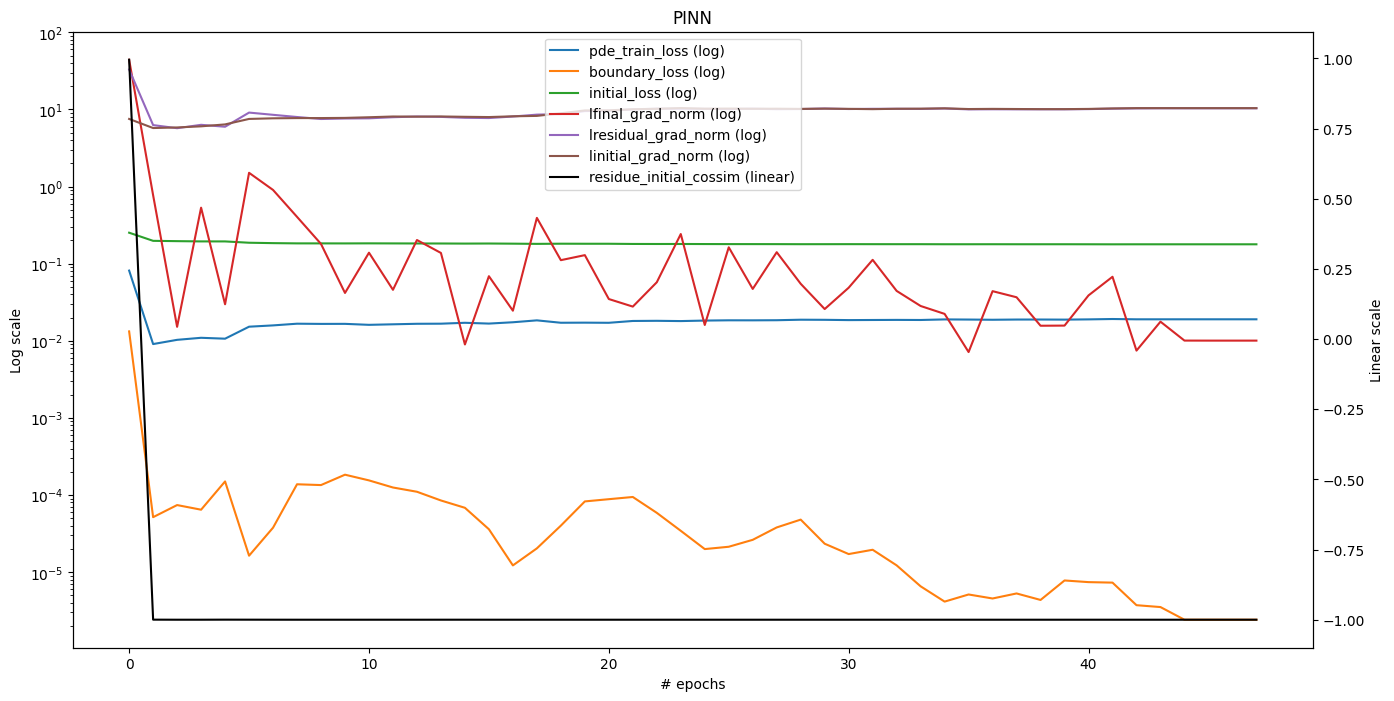

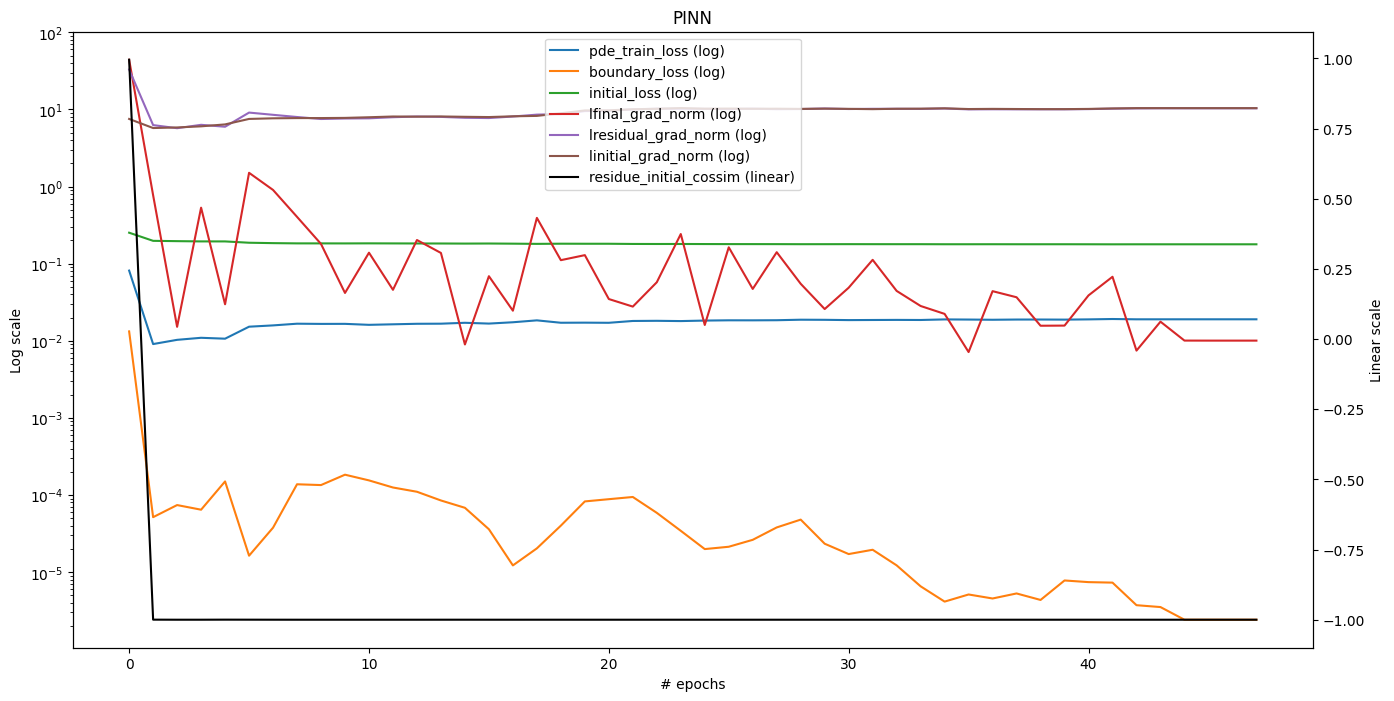

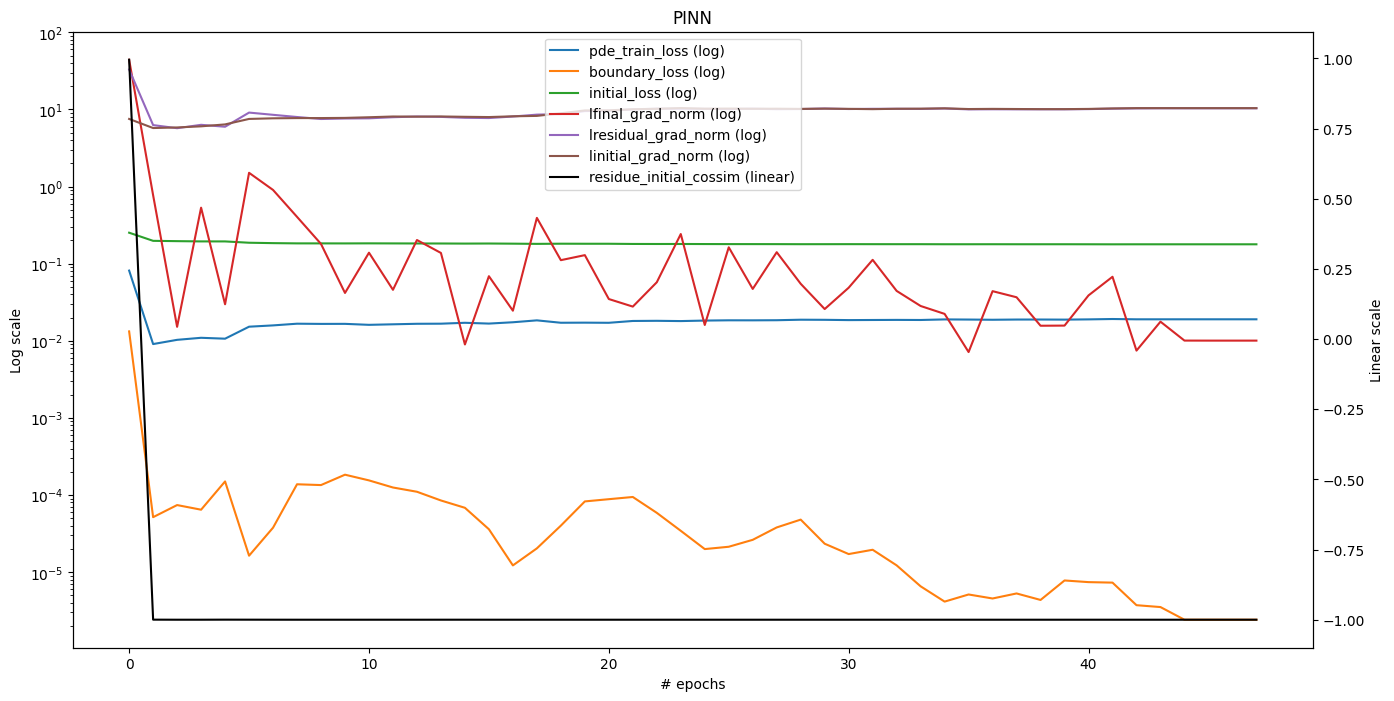

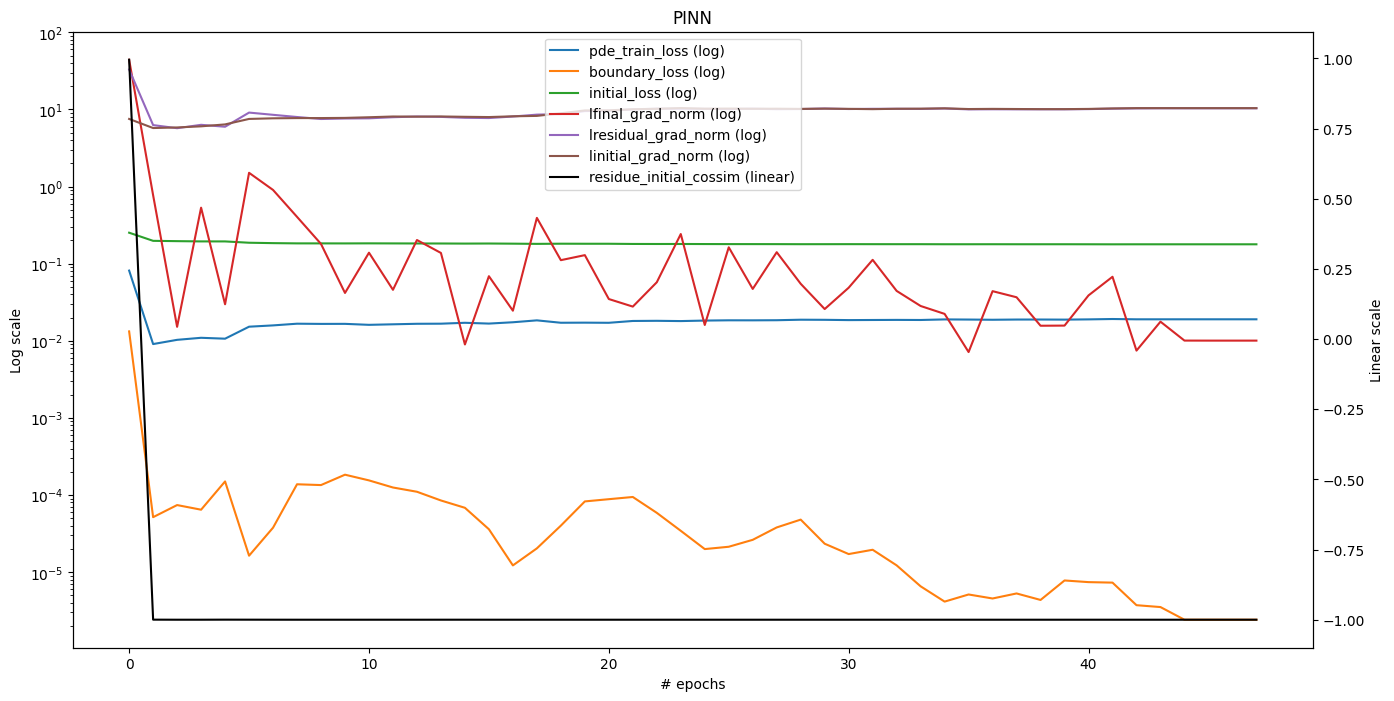

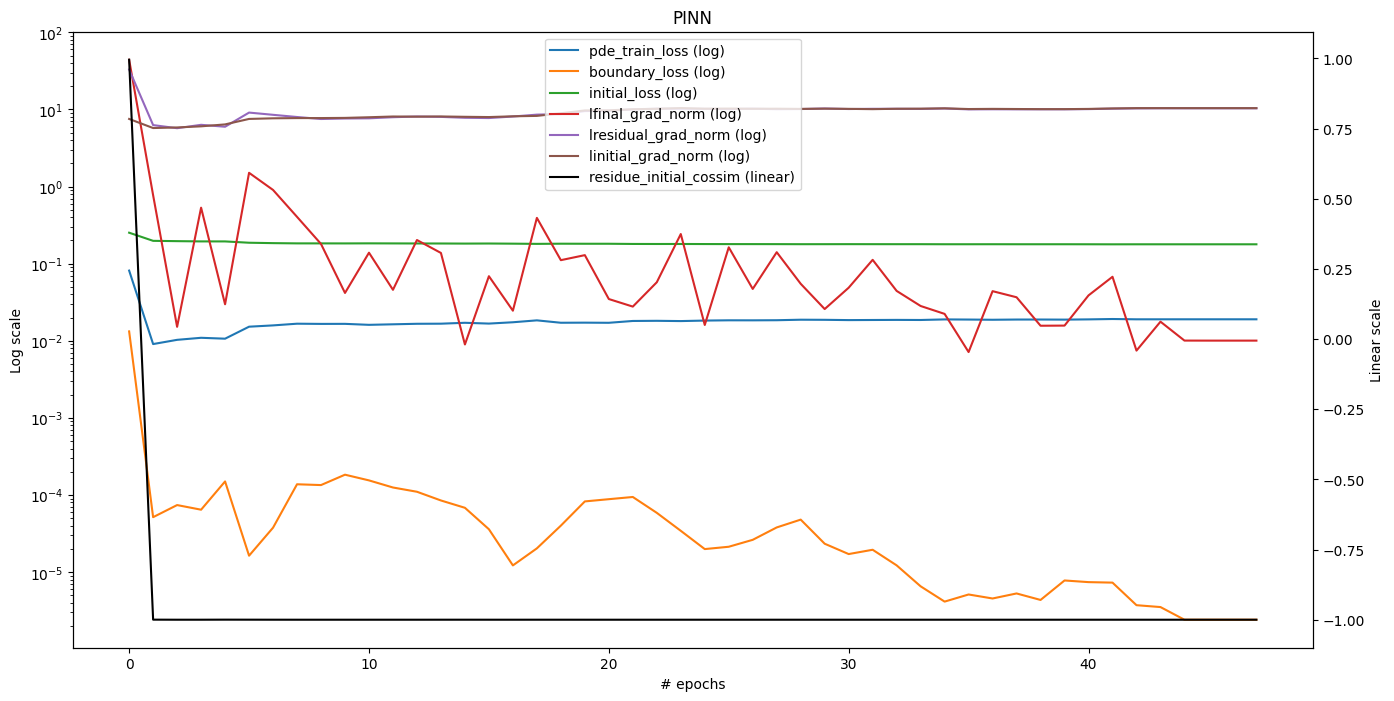

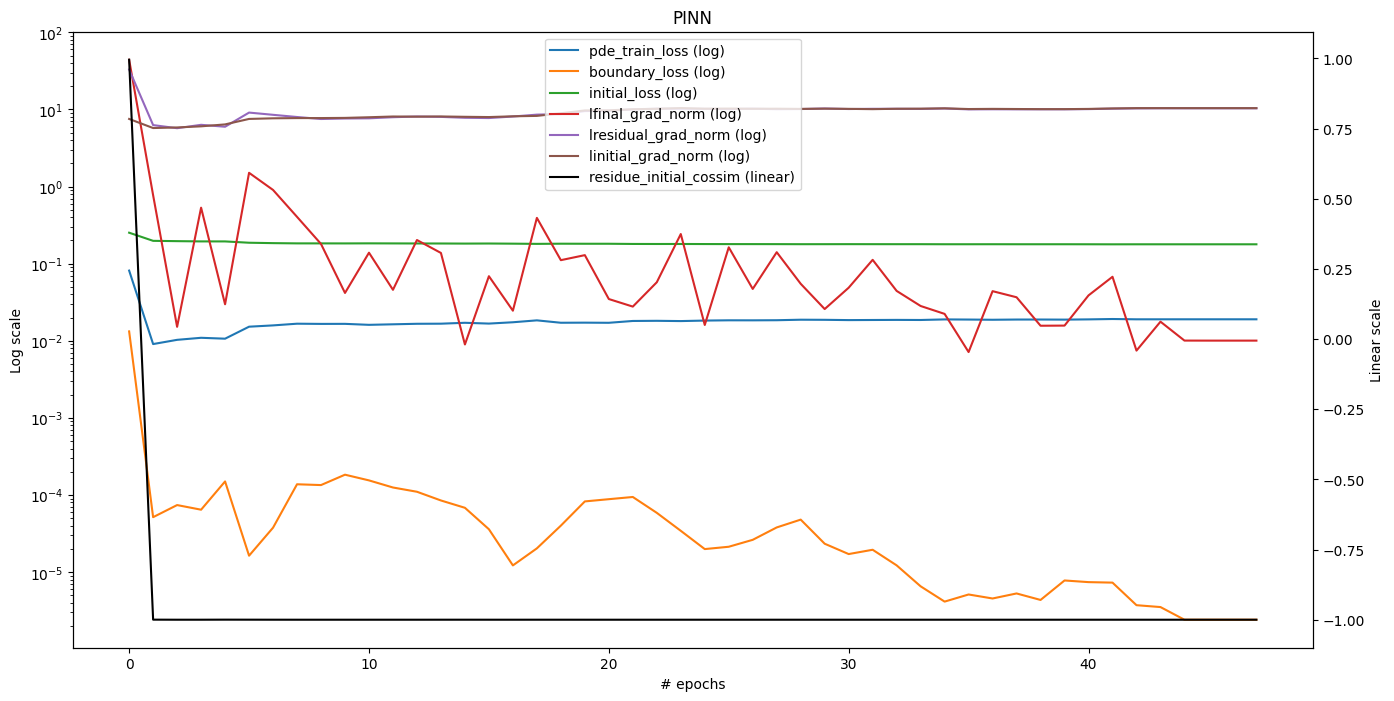

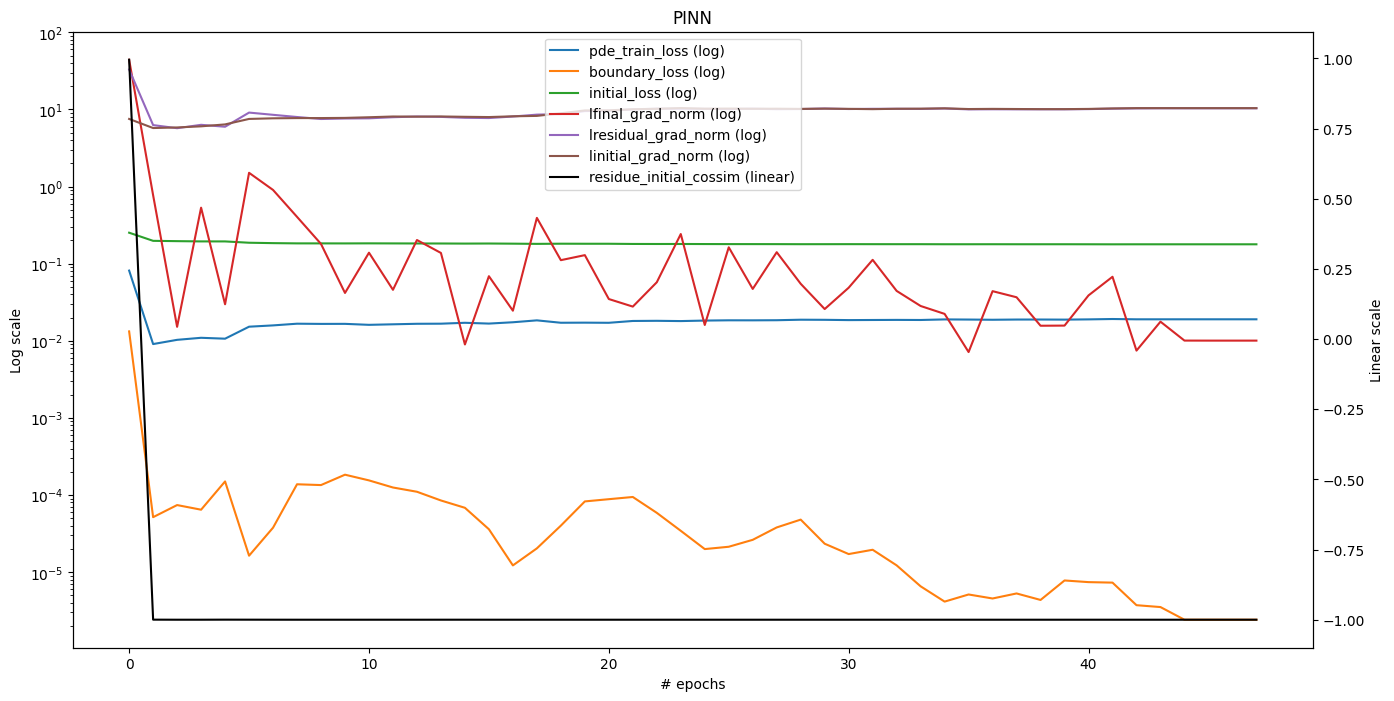

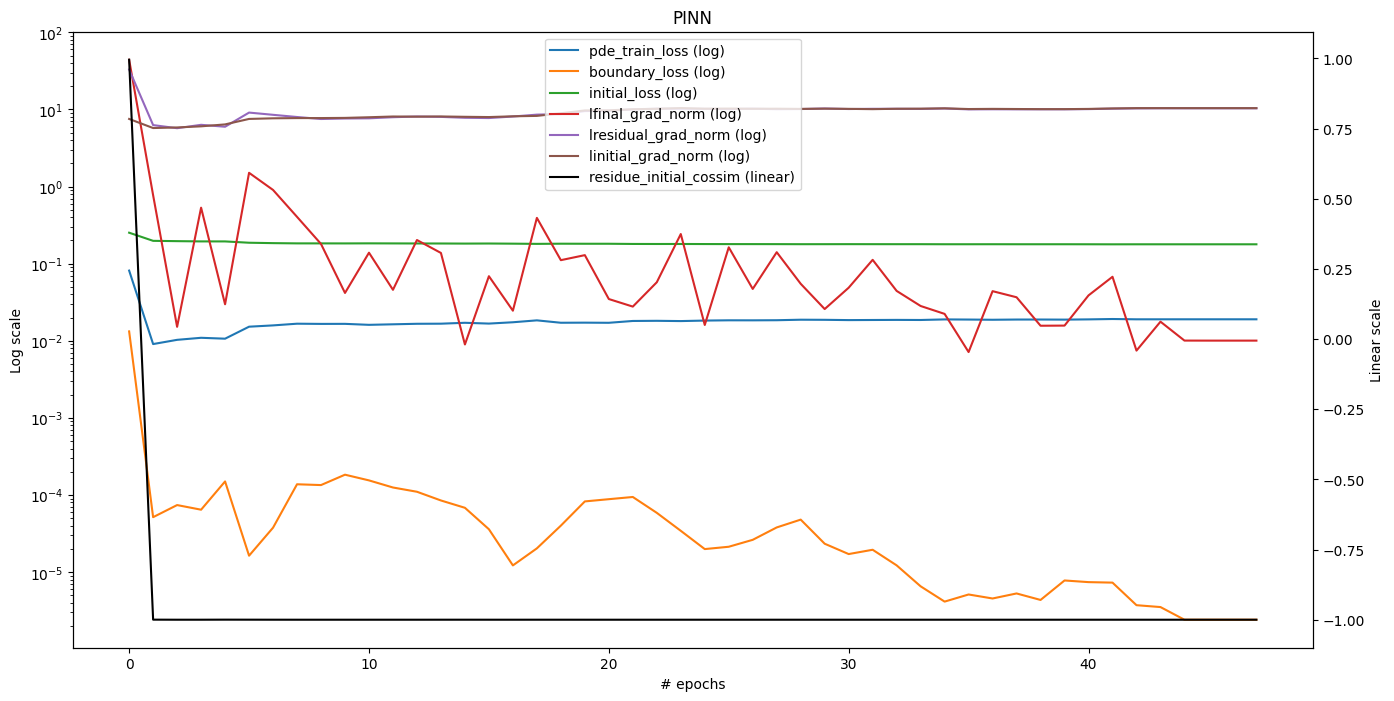

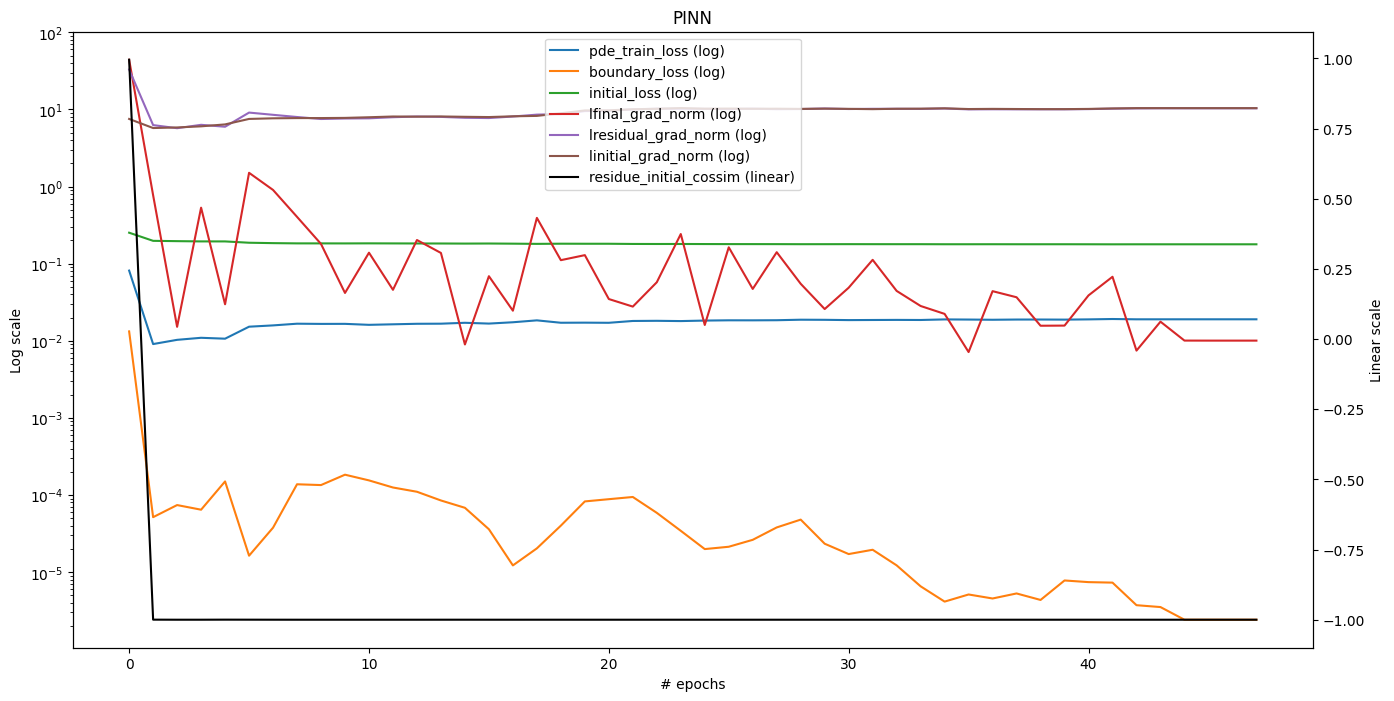

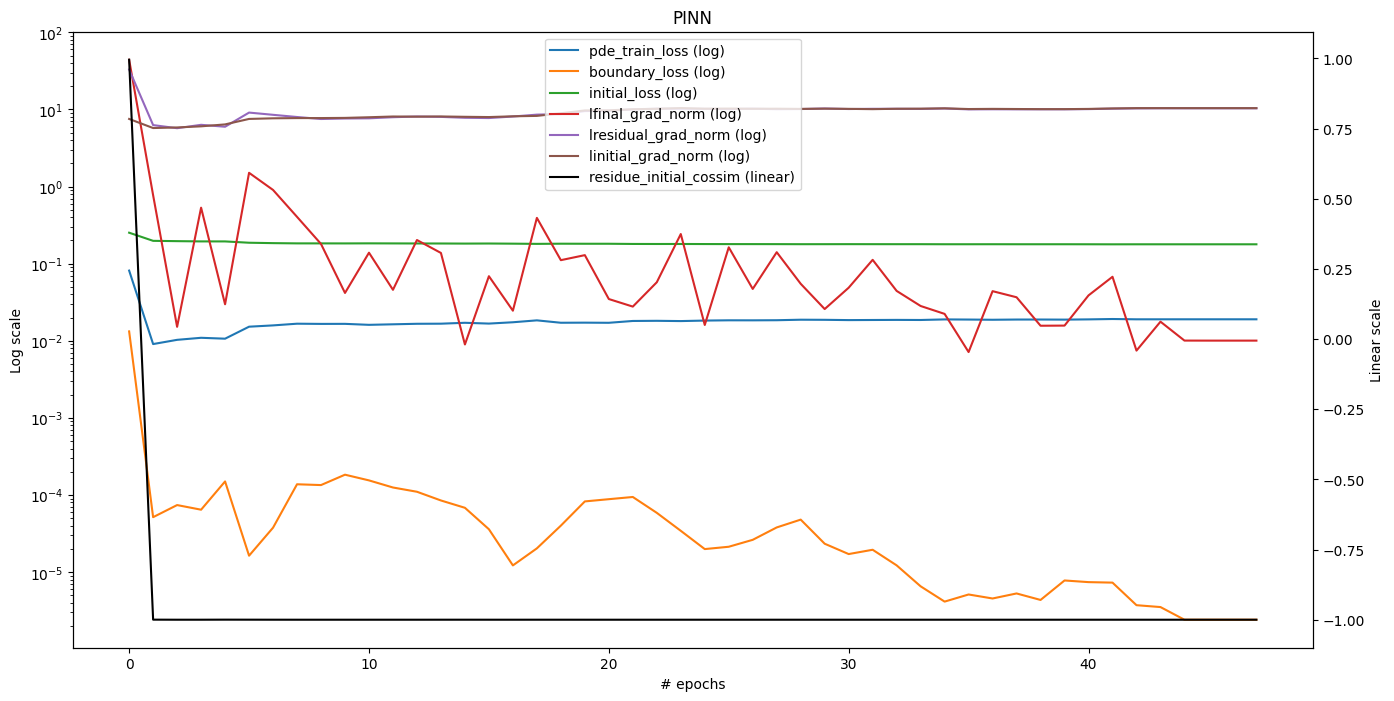

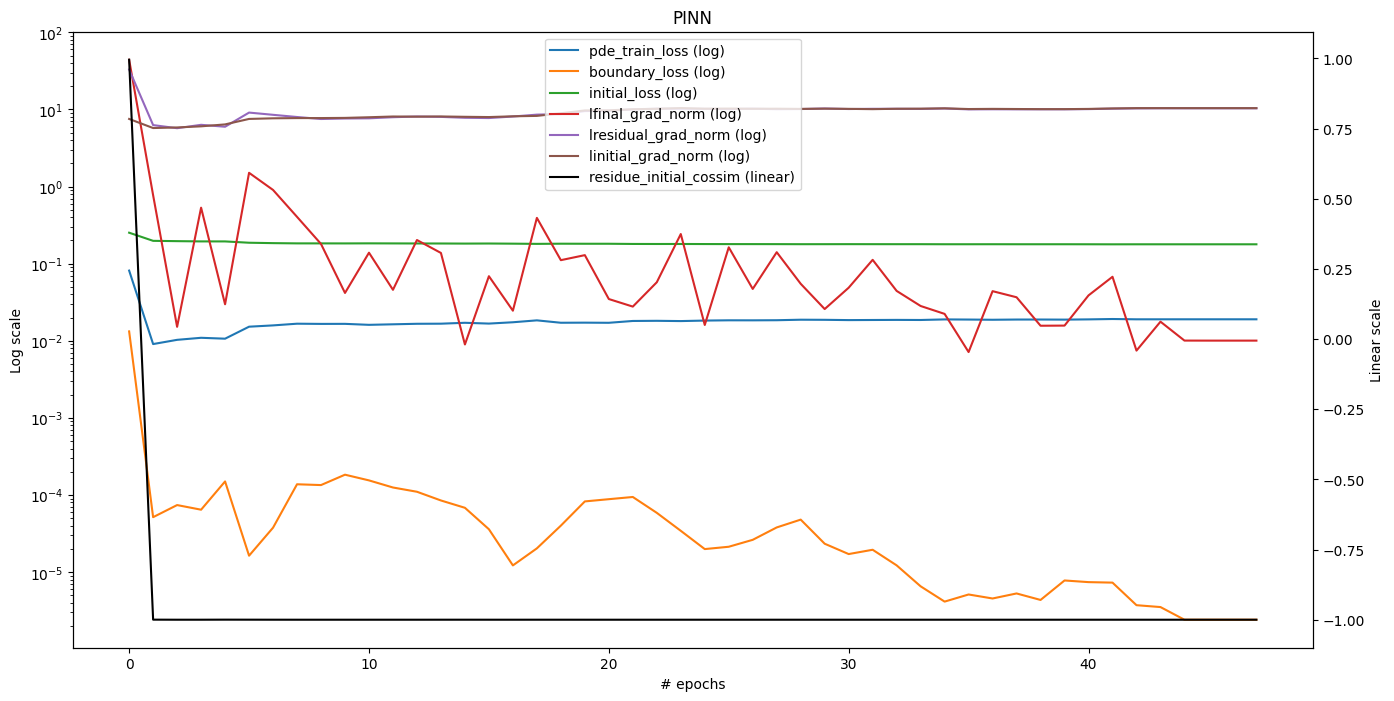

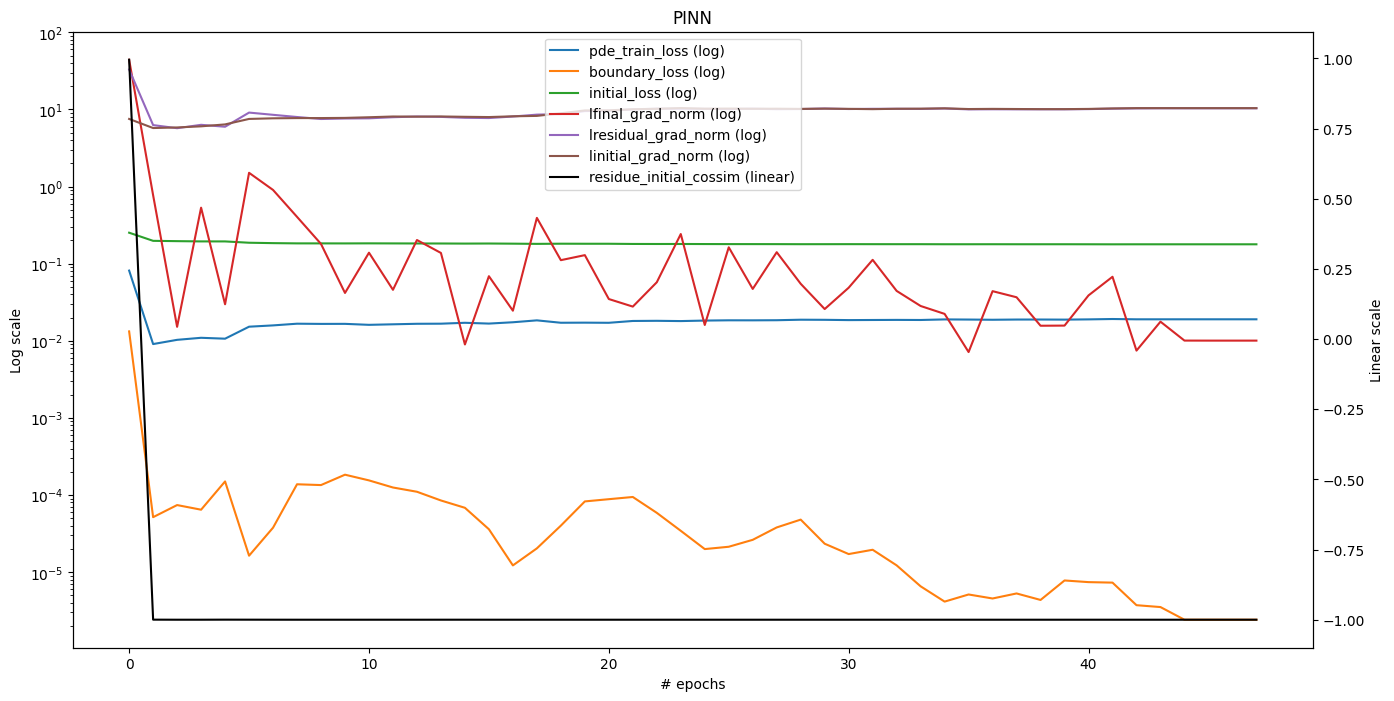

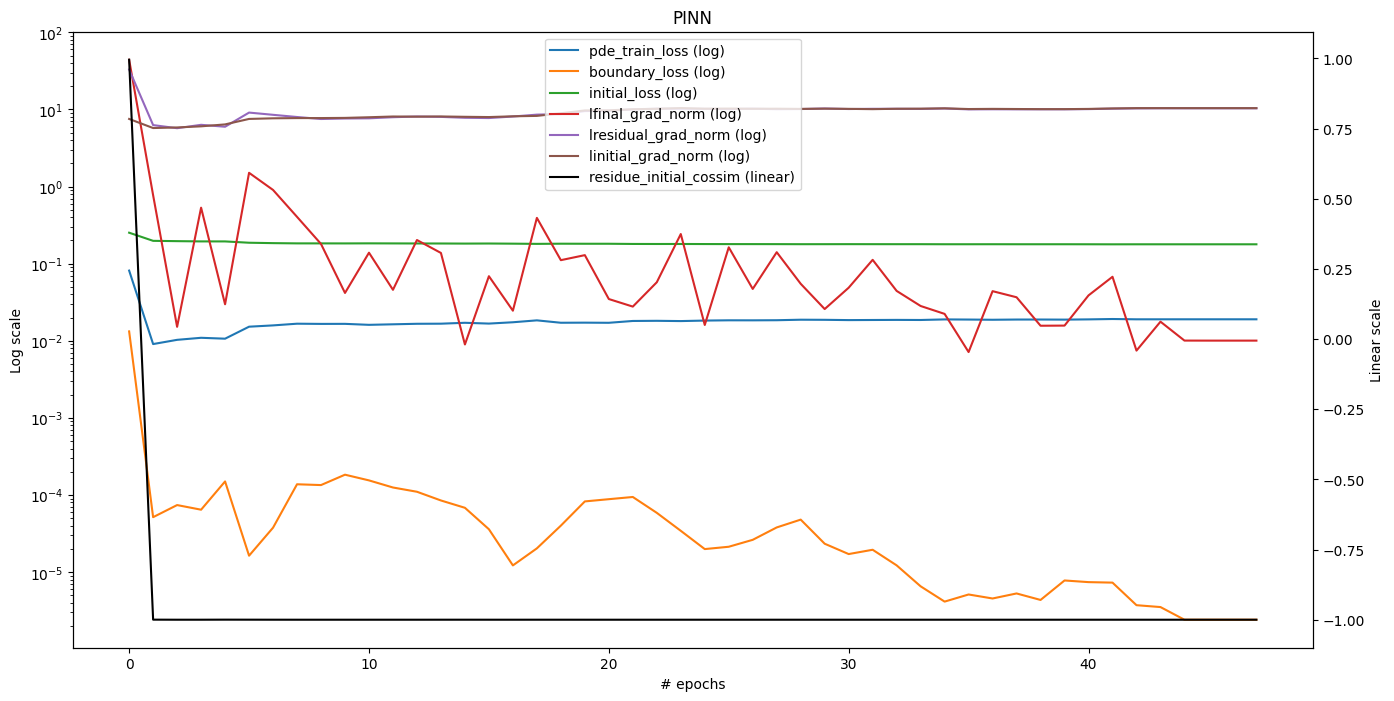

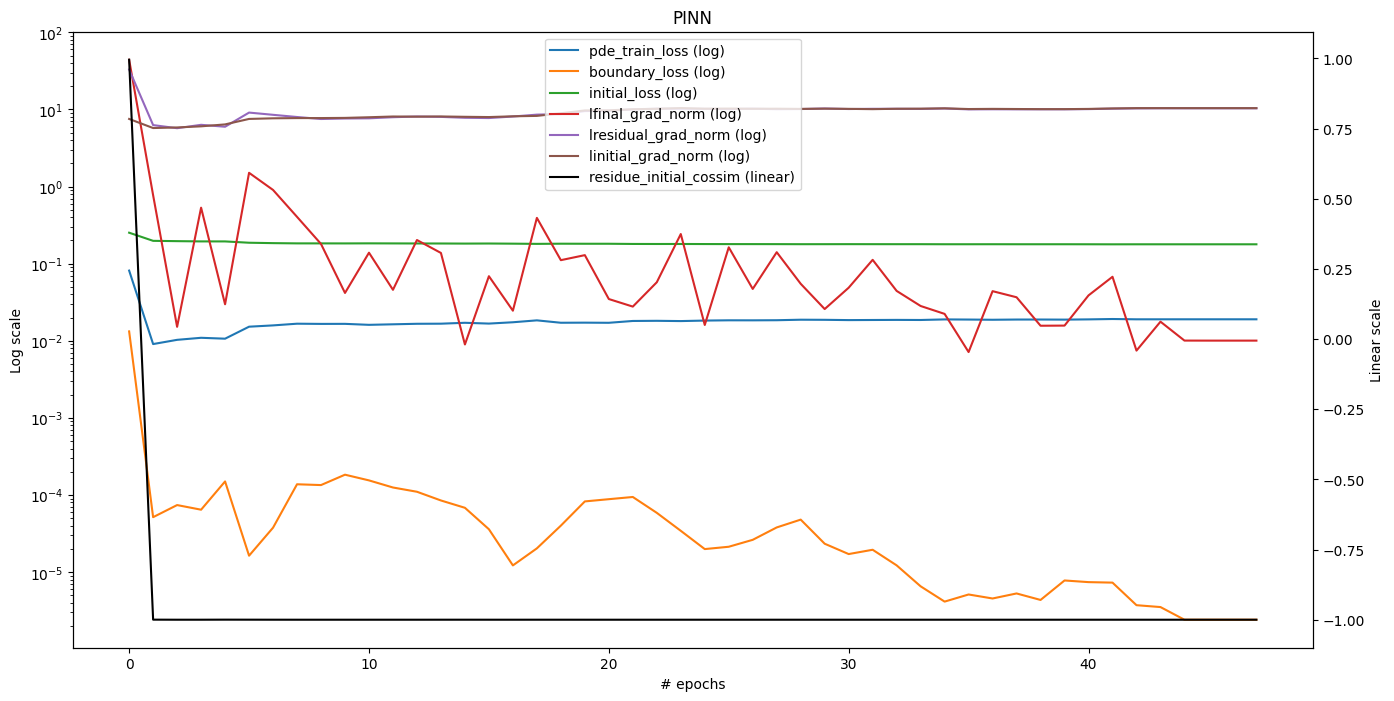

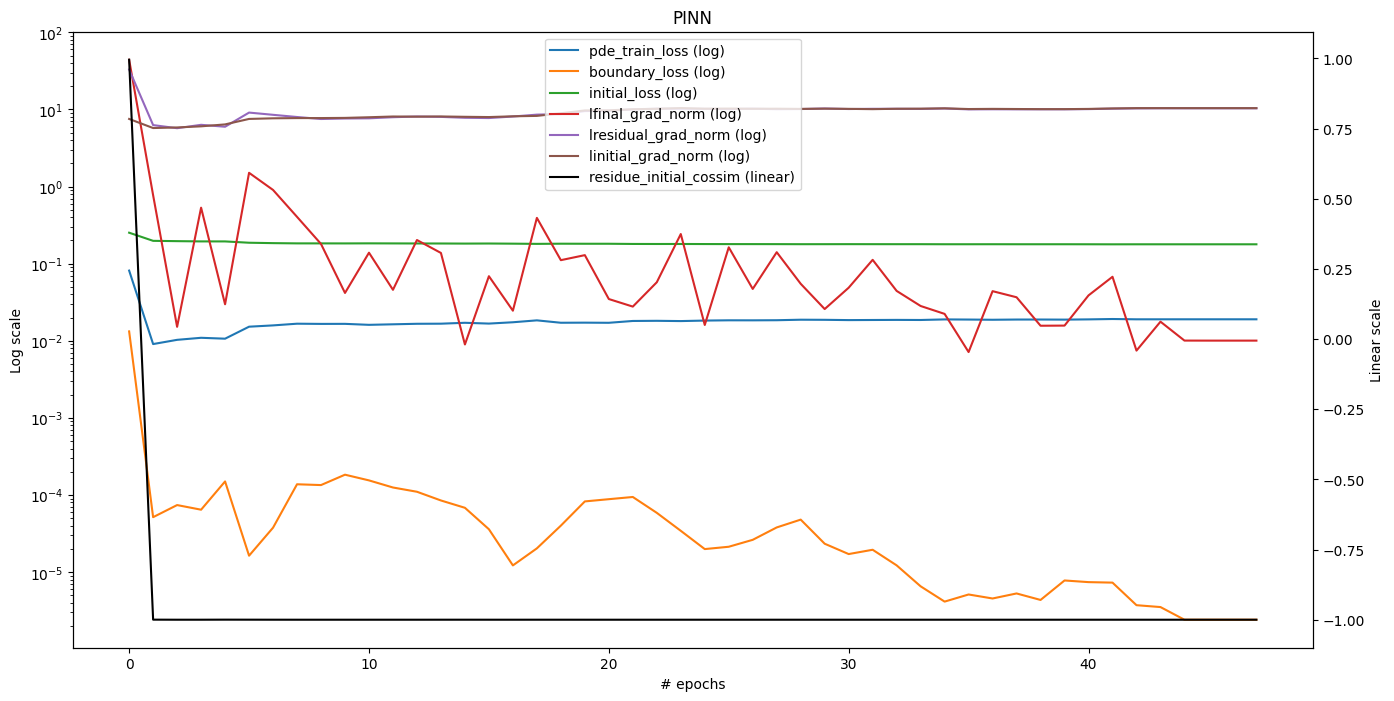

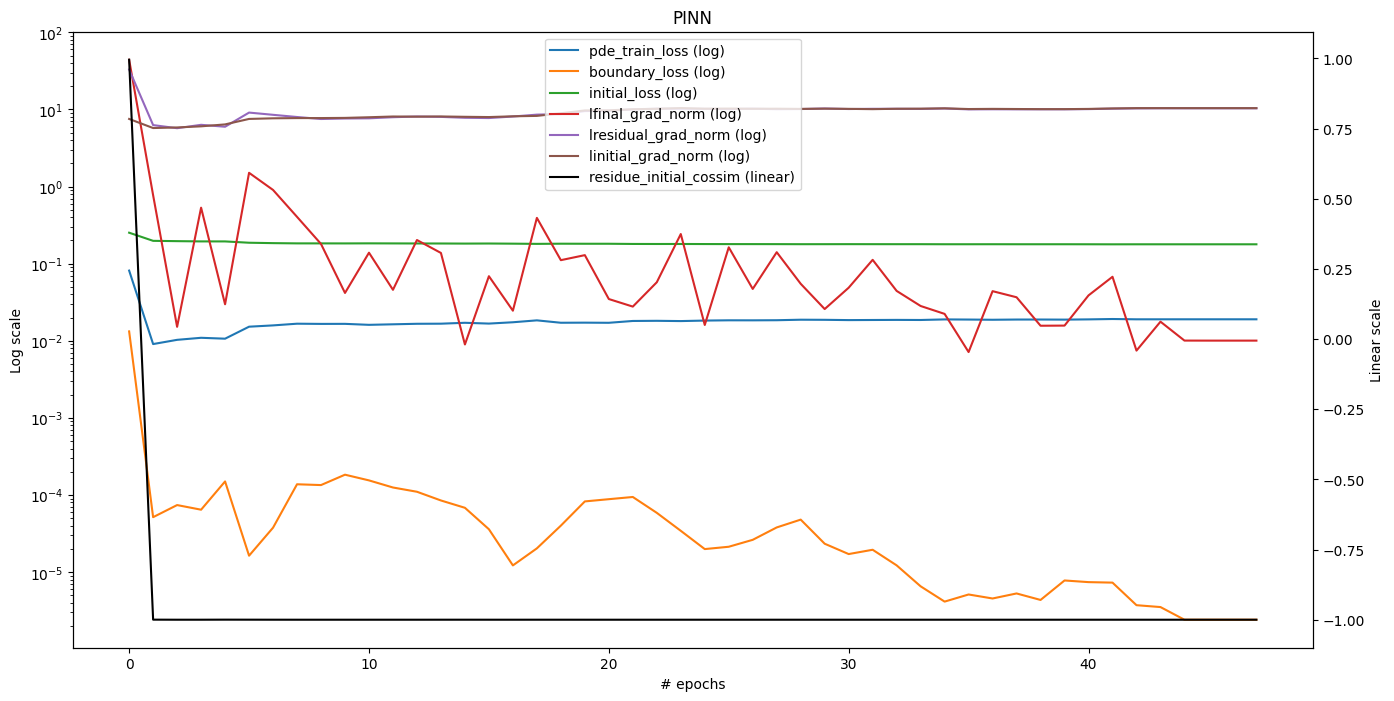

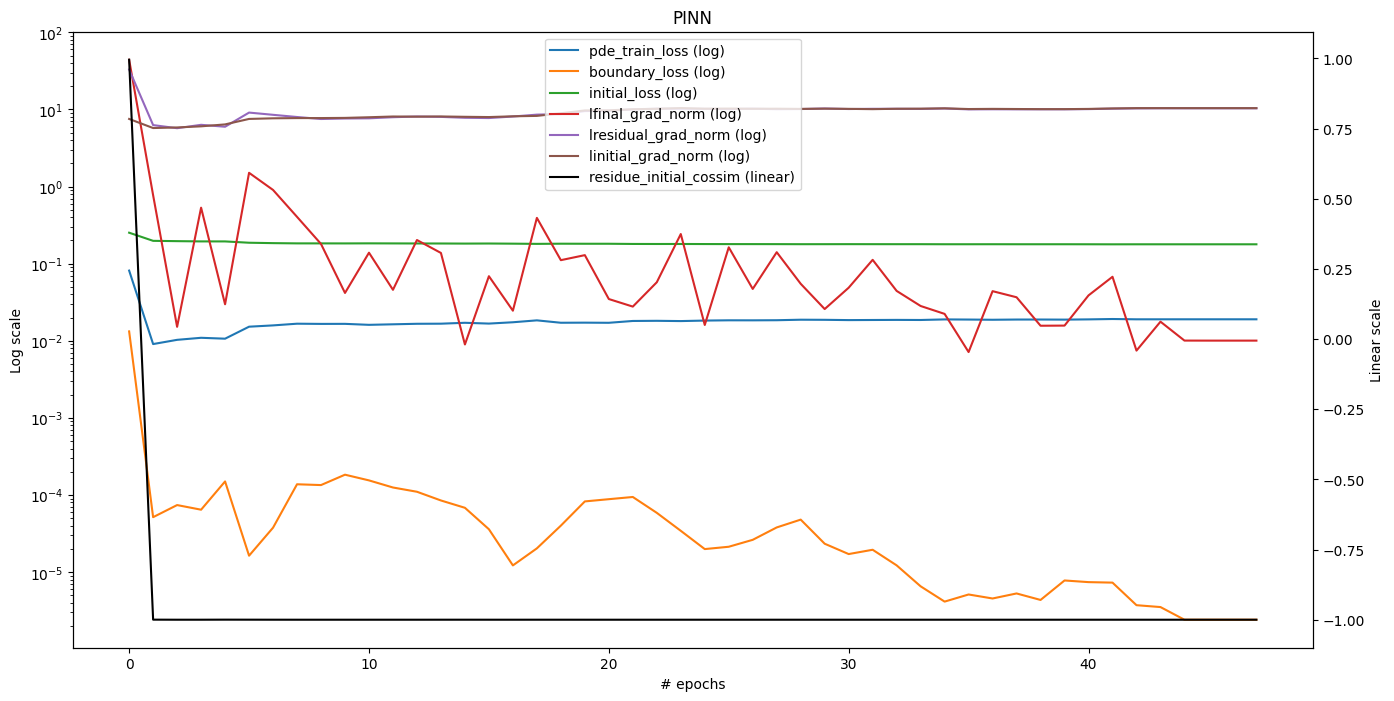

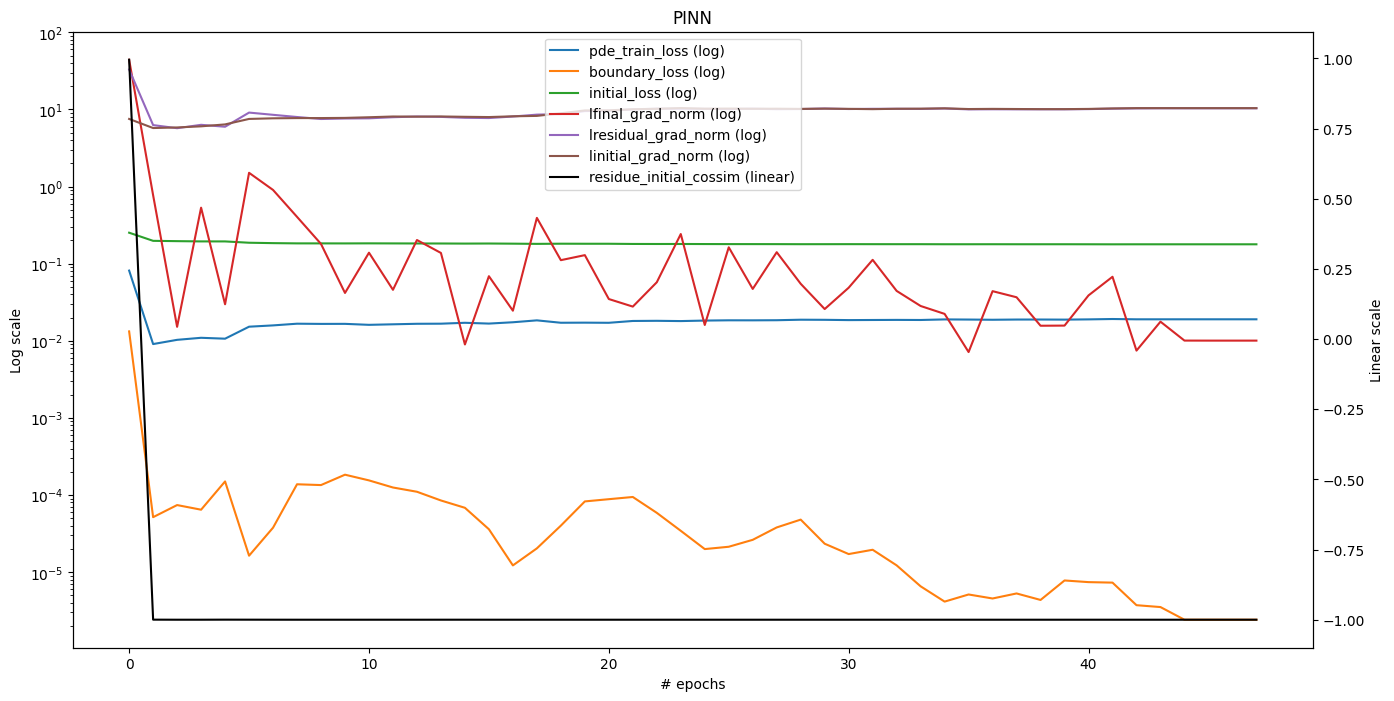

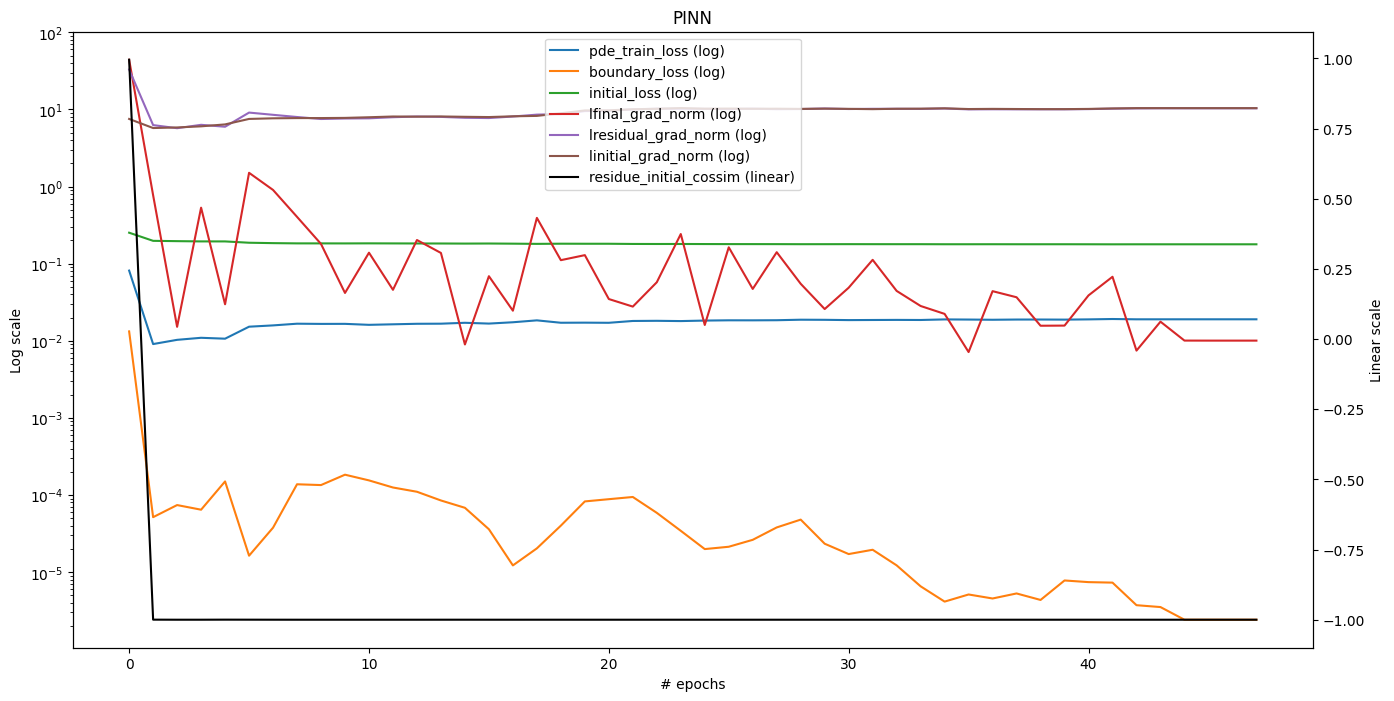

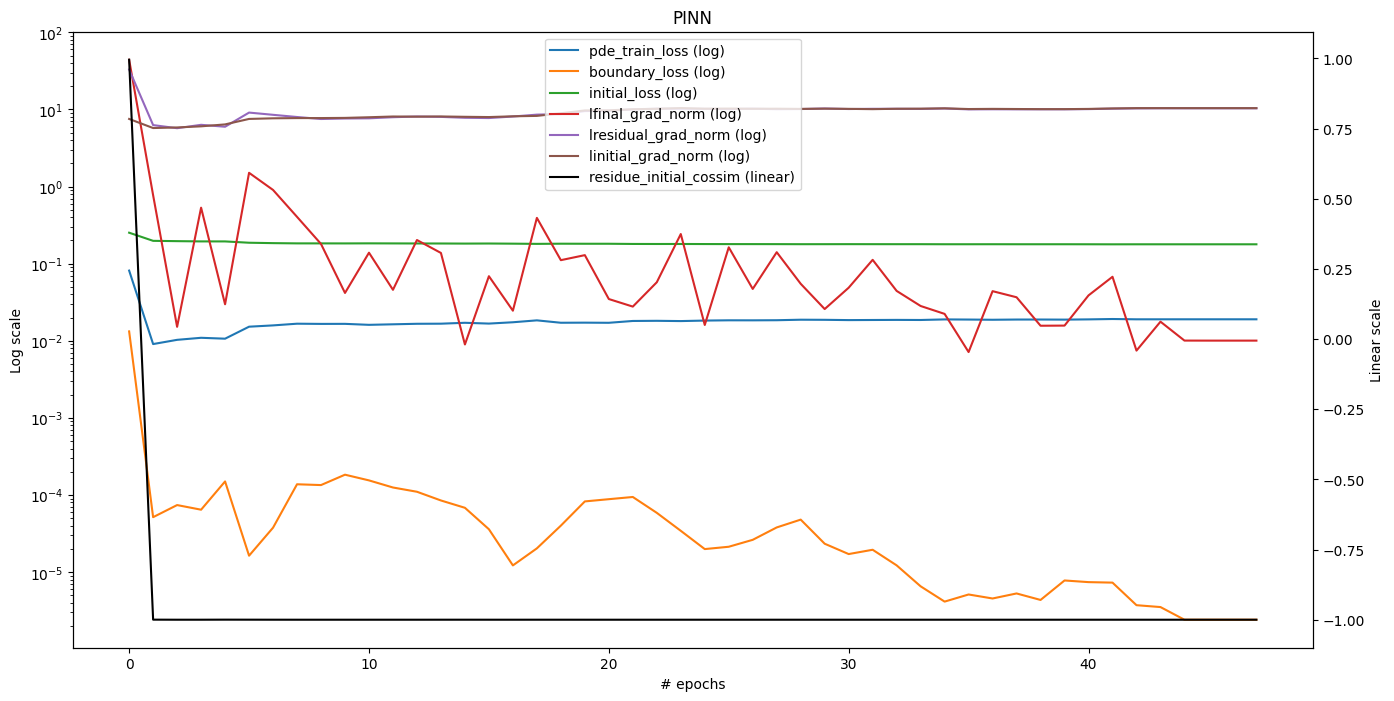

KeyboardInterrupt: 

In [35]:
for seed in INIT_SEEDS:
    train_history_plot(data_path, analysis_path, model_names[0], 5, cosine_indices = [0,1,3,8])